# Amazon A/B Testing: Statistical Analysis & Results

An A/B test is a randomized experiment used to compare two versions of a variable (Group A vs. Group B) to determine which one performs better in a specific business environment. 

In this notebook, we will rigorously test if the new website design (Group B) successfully drives more revenue and engagement than the current control version (Group A), backing our business decisions with statistical evidence.

In [ ]:
# Data manipulation
import pandas as pd
pd.set_option('display.max_columns', None)

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# System paths for custom modules
import sys
sys.path.append('../')

# Custom statistical functions
from src import abtest as ab

In [ ]:
df=pd.read_csv('../data/data_processed.csv')
df.sample(5)

In [ ]:
df['group'].unique()

In [ ]:
ab.explore_ab_groups(df,'group')

In [ ]:
df.sample(5)

### Key Metrics for the A/B Test

To determine if the new website variant (Group B) successfully outperforms the current control version (Group A), we will evaluate the following Key Performance Indicators (KPIs):

- Conversion
- Total_value
- session_duration
- quantity

### 1. Visual Exploratory Data Analysis (EDA)

Before diving into complex statistical algorithms, it is crucial to visually inspect the differences between the two groups across our Key Performance Indicators (KPIs). The bar plots below display the mean values for each group, with error bars indicating the confidence intervals. This gives us an initial intuition of the test's direction.

Text(0.5, 1.0, 'Quantity')

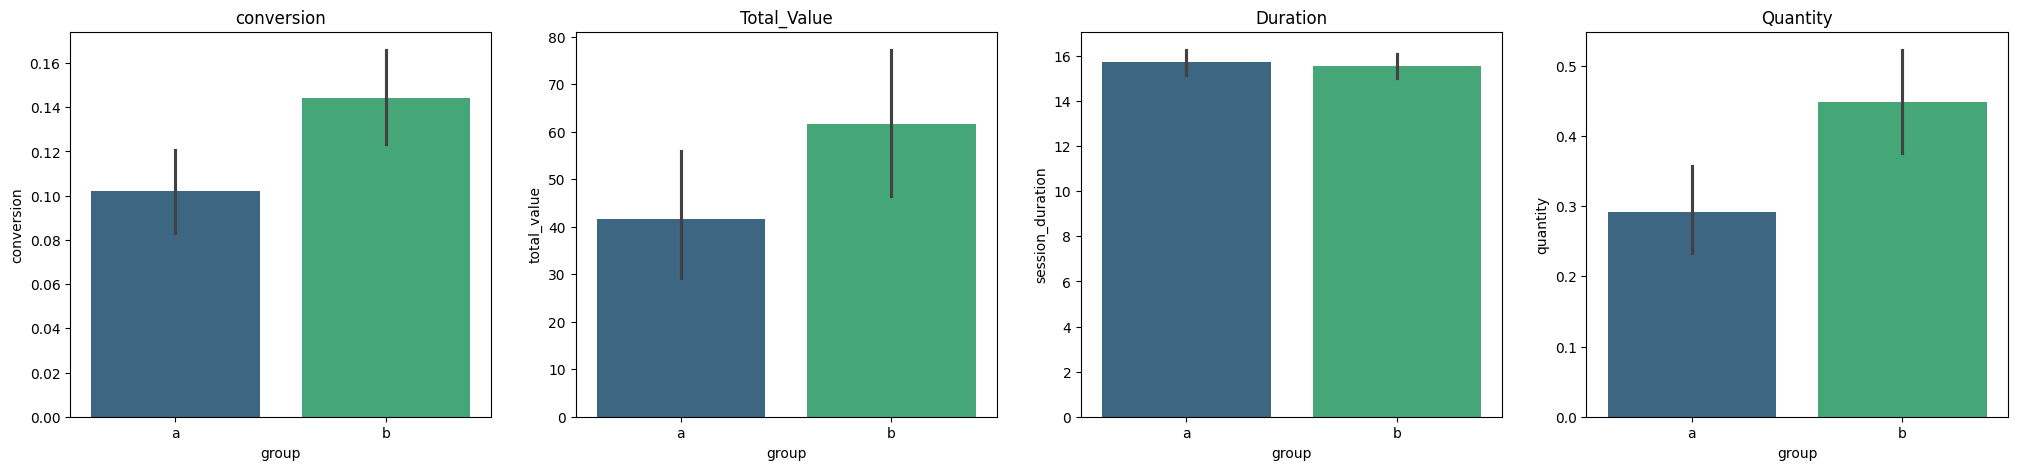

In [8]:
fig,axes=plt.subplots(nrows=1,ncols=4,figsize=(25,5))
sns.barplot(x='group',y='conversion',data=df,ax=axes[0],hue='group',palette='viridis')
axes[0].set_title('conversion')
sns.barplot(x='group',y='total_value',data=df,ax=axes[1],hue='group',palette='viridis')
axes[1].set_title('Total_Value')
sns.barplot(x='group',y='session_duration',data=df,ax=axes[2],hue='group',palette='viridis')
axes[2].set_title('Duration')
sns.barplot(x='group',y='quantity',data=df,ax=axes[3],hue='group',palette='viridis')
axes[3].set_title('Quantity')

In [9]:
metrics=['conversion','total_value','session_duration','quantity']

### 2. Testing Statistical Assumptions

To choose the correct mathematical test, we must first check the underlying distribution of our data. 

1. **Normality (Shapiro-Wilk):** We test if our metrics follow a Gaussian "bell curve". As expected in e-commerce (where a few users spend a lot of money), our data is heavily skewed and completely fails the normality test (p < 0.05).
2. **Homoscedasticity (Levene):** We test if the variance (dispersion) is equal across both groups.

In [13]:
ab.check_normality(df, metrics)

--- SHAPIRO-WILK NORMALITY TEST ---
 CONVERSION: p-value=0.0000 -> Data DOES NOT follow a normal distribution.
 TOTAL_VALUE: p-value=0.0000 -> Data DOES NOT follow a normal distribution.
 SESSION_DURATION: p-value=0.0000 -> Data DOES NOT follow a normal distribution.
 QUANTITY: p-value=0.0000 -> Data DOES NOT follow a normal distribution.


In [11]:
ab.check_homoscedasticity(df,'group',metrics)


--- LEVENE'S HOMOSCEDASTICITY TEST ---
CONVERSION: p-value=0.0045 -> Variances are NOT homogeneous (HETEROSCEDASTICITY).
TOTAL_VALUE: p-value=0.0570 -> Variances are homogeneous (HOMOSCEDASTICITY met).
SESSION_DURATION: p-value=0.9952 -> Variances are homogeneous (HOMOSCEDASTICITY met).
QUANTITY: p-value=0.0014 -> Variances are NOT homogeneous (HETEROSCEDASTICITY).


### 3. Hypothesis Testing: Mann-Whitney U Test

Since our data is independent and **not normally distributed**, we cannot use a standard parametric T-Test. Instead, we apply the **Mann-Whitney U Test**, a robust non-parametric method perfectly suited for this scenario.

* **Null Hypothesis (H0):** There is no significant difference between Group A and Group B.
* **Alternative Hypothesis (H1):** There is a statistically significant difference between the groups.
* **Confidence Level:** 95% (We reject H0 if p-value < 0.05).

In [12]:
ab.perform_mann_whitney(df,'group',metrics)


--- MANN-WHITNEY U TEST (Non-Parametric) ---
Testing metric: CONVERSION between a and b
 Result (p=0.0045): SIGNIFICANT DIFFERENCES EXIST between the groups!
------------------------------
Testing metric: TOTAL_VALUE between a and b
 Result (p=0.0038): SIGNIFICANT DIFFERENCES EXIST between the groups!
------------------------------
Testing metric: SESSION_DURATION between a and b
 Result (p=0.6460): NO significant differences between the groups.
------------------------------
Testing metric: QUANTITY between a and b
 Result (p=0.0033): SIGNIFICANT DIFFERENCES EXIST between the groups!
------------------------------


### Final Conclusion

The A/B test is a resounding success for the new variant (**Group B**).

* **Revenue & Conversion:** Group B significantly increased both the Conversion Rate (p=0.0045) and the Total Value spent (p=0.0038). 
* **Volume:** Users in the new variant bought significantly more items per transaction (Quantity, p=0.0033).
* **Engagement:** The Session Duration remained statistically identical (p=0.6460). This is actually a positive outcome: the new design drives more sales and higher cart sizes without forcing users to spend more time navigating the site.

**Executive Recommendation:** Deploy the Group B variant to 100% of the user base immediately.